In [1]:
# Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
#Machine Learning (ML) library: Sci-kit learn(sklearn)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit

In [2]:
#Load the data with pandas
df = pd.read_excel(r"C:\Users\DELL\Downloads\Volve production data.xlsx")
df

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.07776,0.22879,0.01862,0.0,0.0,0.0,NaN,production,OP
15630,2016-09-15,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.08545,0.22914,0.00631,0.0,0.0,0.0,NaN,production,OP
15631,2016-09-16,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.08544,0.22896,0.01181,0.0,0.0,0.0,NaN,production,OP
15632,2016-09-17,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.07497,0.22846,0.02576,0.0,0.0,0.0,NaN,production,OP


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[us]
 1   WELL_BORE_CODE            15634 non-null  str           
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  str           
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  str           
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  str           
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNULUS_PRESS         789

In [8]:
#Quick Inpsection
print(f"Dataset shape:{df.shape}")
print(f"Columns:{df.columns.tolist()}")

Dataset shape:(15634, 24)
Columns:['DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WI_VOL', 'FLOW_KIND', 'WELL_TYPE']


In [9]:
df.isnull().sum()

DATEPRD                        0
WELL_BORE_CODE                 0
NPD_WELL_BORE_CODE             0
NPD_WELL_BORE_NAME             0
NPD_FIELD_CODE                 0
NPD_FIELD_NAME                 0
NPD_FACILITY_CODE              0
NPD_FACILITY_NAME              0
ON_STREAM_HRS                285
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DP_TUBING               6654
AVG_ANNULUS_PRESS           7744
AVG_CHOKE_SIZE_P            6715
AVG_CHOKE_UOM               6473
AVG_WHP_P                   6479
AVG_WHT_P                   6488
DP_CHOKE_SIZE                294
BORE_OIL_VOL                6473
BORE_GAS_VOL                6473
BORE_WAT_VOL                6473
BORE_WI_VOL                 9928
FLOW_KIND                      0
WELL_TYPE                      0
dtype: int64

In [10]:
#Data cleaning
#Convert data column
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'])
#Identify wells (unique well coded)
wells = df['WELL_BORE_CODE'].unique()
print(f"Wells in dataset: {wells}")

Wells in dataset: <ArrowStringArray>
[ 'NO 15/9-F-1 C', 'NO 15/9-F-11 H', 'NO 15/9-F-12 H', 'NO 15/9-F-14 H',
 'NO 15/9-F-15 D', 'NO 15/9-F-4 AH', 'NO 15/9-F-5 AH']
Length: 7, dtype: str


In [11]:
#Check production vs non-production periods
df['ON_STREAM_HRS'].describe()

count    15349.000000
mean        19.994093
std          8.369978
min          0.000000
25%         24.000000
50%         24.000000
75%         24.000000
max         25.000000
Name: ON_STREAM_HRS, dtype: float64

In [12]:
#Feature Engineering
#Create derived features
df['DATE'] = pd.to_datetime(df['DATEPRD'])
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df['DAY'] = df['DATE'].dt.day
df['DAYOFYEAR'] = df['DATE'].dt.dayofyear

#calculate fluid ratios
df['GOR'] = df['BORE_GAS_VOL'] / df['BORE_OIL_VOL'].replace(0, np.nan)
#Gas oil ratio
df['WCUT'] = df['BORE_WAT_VOL'] / df['BORE_OIL_VOL'] + (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL']).replace(0, np.nan) #Water Cut

#Operating efficiency
df['EFFICIENCY'] = df['ON_STREAM_HRS'] / 24 #Daily efficiency(0-1)

#Pressure differential
df['DP_RESERVOIR'] = df['AVG_DOWNHOLE_PRESSURE'] - df['AVG_WHP_P']

Wells found: <ArrowStringArray>
[ 'NO 15/9-F-1 C', 'NO 15/9-F-11 H', 'NO 15/9-F-12 H', 'NO 15/9-F-14 H',
 'NO 15/9-F-15 D', 'NO 15/9-F-4 AH', 'NO 15/9-F-5 AH']
Length: 7, dtype: str


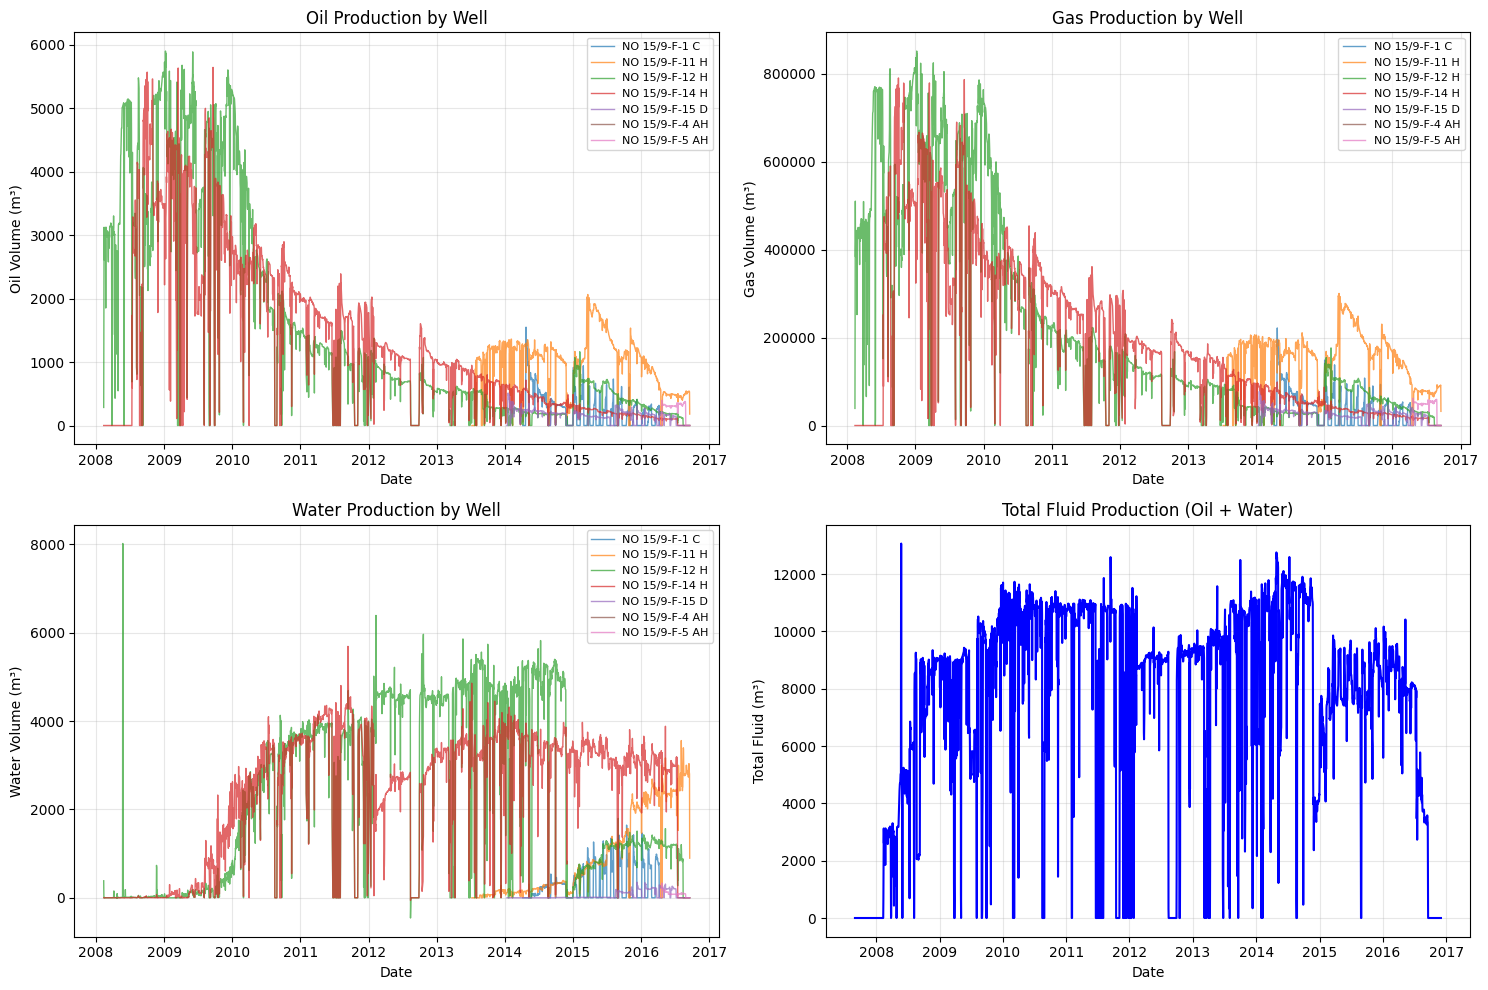


PRODUCTION SUMMARY

NO 15/9-F-1 C:
  Total Oil: 177,709 m³
  Total Gas: 26,440,919 m³
  Total Water: 207,302 m³
  Active Days: 438

NO 15/9-F-11 H:
  Total Oil: 1,147,849 m³
  Total Gas: 174,310,521 m³
  Total Water: 1,090,806 m³
  Active Days: 1122

NO 15/9-F-12 H:
  Total Oil: 4,579,610 m³
  Total Gas: 667,542,278 m³
  Total Water: 6,833,320 m³
  Active Days: 2838

NO 15/9-F-14 H:
  Total Oil: 3,942,233 m³
  Total Gas: 578,009,542 m³
  Total Water: 7,121,250 m³
  Active Days: 2724

NO 15/9-F-15 D:
  Total Oil: 148,519 m³
  Total Gas: 22,505,351 m³
  Total Water: 52,366 m³
  Active Days: 769

NO 15/9-F-4 AH:
  Total Oil: 0 m³
  Total Gas: 0 m³
  Total Water: 0 m³
  Active Days: 2830

NO 15/9-F-5 AH:
  Total Oil: 41,161 m³
  Total Gas: 6,561,826 m³
  Total Water: 13,533 m³
  Active Days: 2676


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#EDA--> Exploratory Data Analysis
#Production Profile Analysis

# Load data (adjust path as needed)
df = pd.read_excel('Volve production data.xlsx', sheet_name='Daily Production Data')
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'])

# Get unique wells
wells = df['WELL_BORE_CODE'].unique()
print(f"Wells found: {wells}")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Oil Production
for well in wells:
    well_data = df[df['WELL_BORE_CODE'] == well]
    axes[0, 0].plot(well_data['DATEPRD'], well_data['BORE_OIL_VOL'], 
                    label=well, alpha=0.7, linewidth=1)
axes[0, 0].set_title('Oil Production by Well', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Oil Volume (m³)')
axes[0, 0].legend(loc='best', fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 2. Gas Production
for well in wells:
    well_data = df[df['WELL_BORE_CODE'] == well]
    axes[0, 1].plot(well_data['DATEPRD'], well_data['BORE_GAS_VOL'], 
                    label=well, alpha=0.7, linewidth=1)
axes[0, 1].set_title('Gas Production by Well', fontsize=12)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Gas Volume (m³)')
axes[0, 1].legend(loc='best', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# 3. Water Production
for well in wells:
    well_data = df[df['WELL_BORE_CODE'] == well]
    axes[1, 0].plot(well_data['DATEPRD'], well_data['BORE_WAT_VOL'], 
                    label=well, alpha=0.7, linewidth=1)
axes[1, 0].set_title('Water Production by Well', fontsize=12)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Water Volume (m³)')
axes[1, 0].legend(loc='best', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 4. Total Fluid Production
df_total = df.groupby('DATEPRD')[['BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL']].sum()
df_total['TOTAL_FLUID'] = df_total['BORE_OIL_VOL'] + df_total['BORE_WAT_VOL']
axes[1, 1].plot(df_total.index, df_total['TOTAL_FLUID'], 'b-', linewidth=1.5)
axes[1, 1].set_title('Total Fluid Production (Oil + Water)', fontsize=12)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Total Fluid (m³)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("PRODUCTION SUMMARY")
print("="*50)
for well in wells:
    well_data = df[df['WELL_BORE_CODE'] == well]
    total_oil = well_data['BORE_OIL_VOL'].sum()
    total_gas = well_data['BORE_GAS_VOL'].sum()
    total_water = well_data['BORE_WAT_VOL'].sum()
    active_days = (well_data['ON_STREAM_HRS'] > 0).sum()
    
    print(f"\n{well}:")
    print(f"  Total Oil: {total_oil:,.0f} m³")
    print(f"  Total Gas: {total_gas:,.0f} m³")
    print(f"  Total Water: {total_water:,.0f} m³")
    print(f"  Active Days: {active_days}")

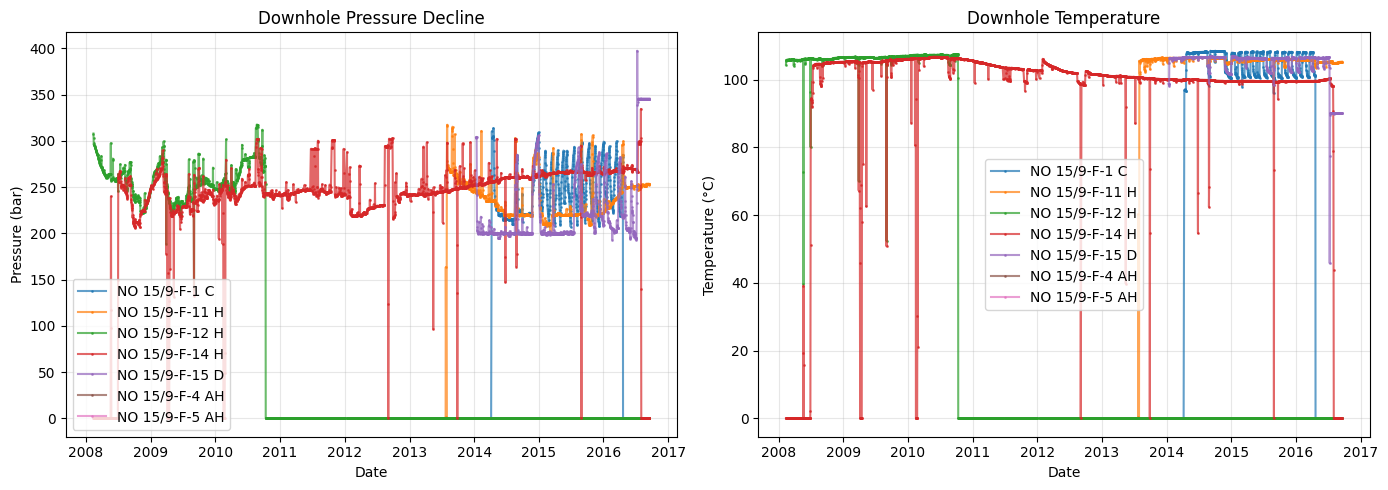

In [14]:
#Pressure & Temperature Analysis
# Pressure decline analysis (reservoir depletion)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for well in wells:
    well_data = df[df['WELL_BORE_CODE'] == well].dropna(subset=['AVG_DOWNHOLE_PRESSURE'])
    axes[0].plot(well_data['DATEPRD'], well_data['AVG_DOWNHOLE_PRESSURE'], 
                 label=well, alpha=0.7, marker='.', linestyle='-', markersize=2)

axes[0].set_title('Downhole Pressure Decline')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Pressure (bar)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Temperature
for well in wells:
    well_data = df[df['WELL_BORE_CODE'] == well].dropna(subset=['AVG_DOWNHOLE_TEMPERATURE'])
    axes[1].plot(well_data['DATEPRD'], well_data['AVG_DOWNHOLE_TEMPERATURE'], 
                 label=well, alpha=0.7, marker='.', linestyle='-', markersize=2)

axes[1].set_title('Downhole Temperature')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

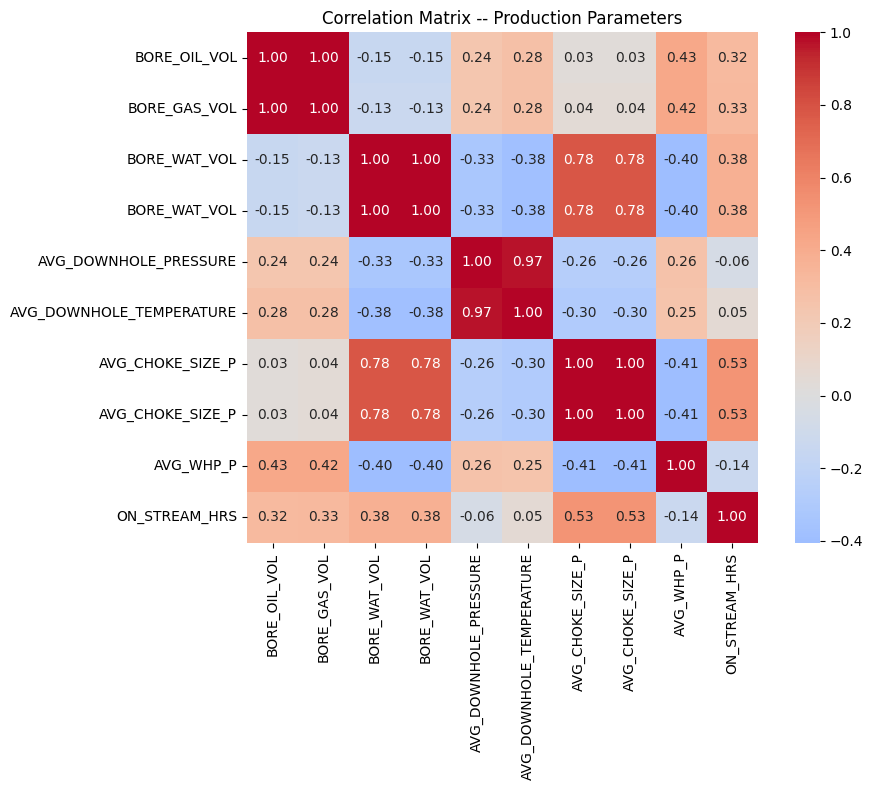

In [15]:
#-->Correlation & Relationships
#Correlation matrix for key parameters
key_cols = ['BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WAT_VOL','AVG_DOWNHOLE_PRESSURE','AVG_DOWNHOLE_TEMPERATURE','AVG_CHOKE_SIZE_P','AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'ON_STREAM_HRS']
corr_df = df[key_cols].dropna()
correlation_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',square=True)
plt.title('Correlation Matrix -- Production Parameters')
plt.tight_layout()
plt.show()

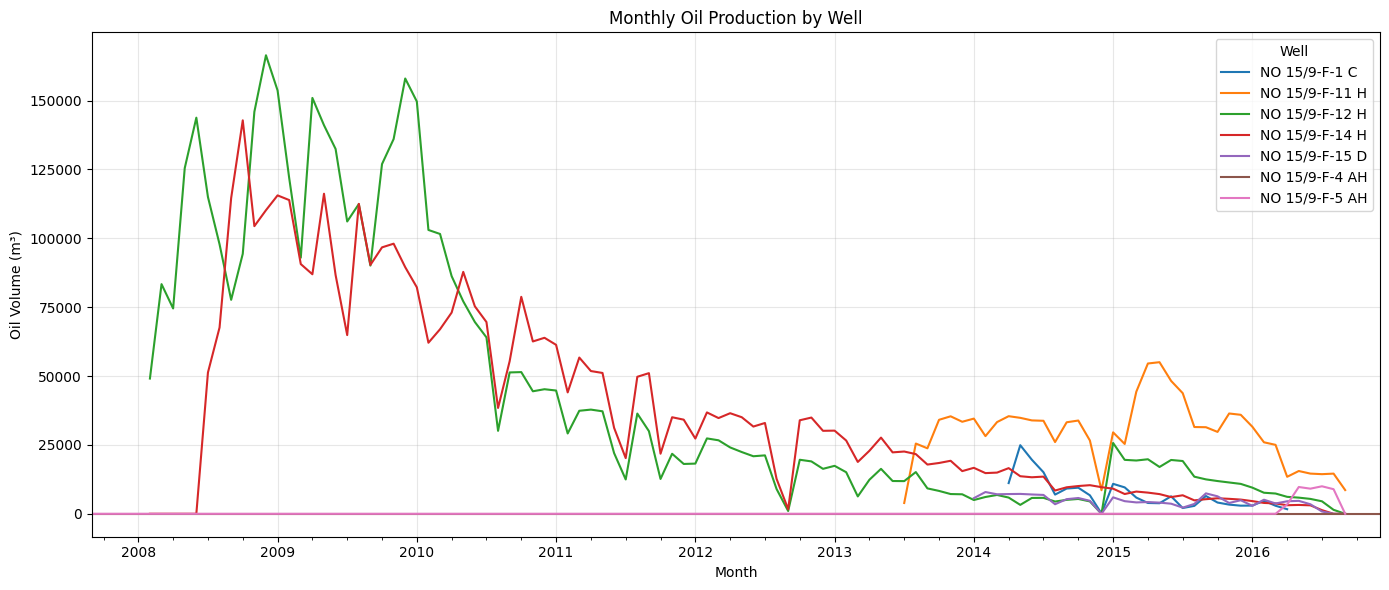

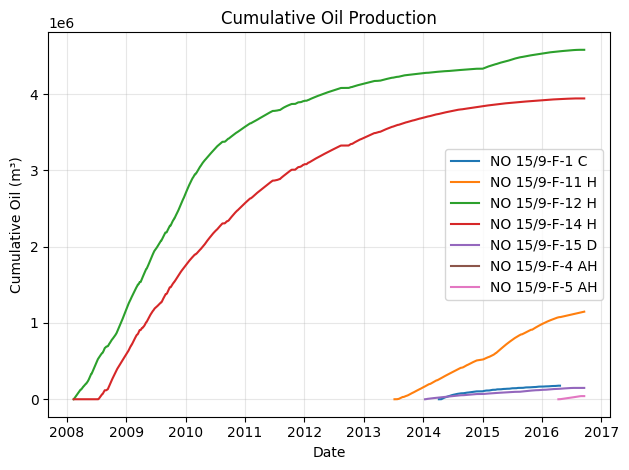

In [16]:
#--> Well Performance Comparison
# Monthly production summary
df['YEAR_MONTH'] = df['DATEPRD'].dt.to_period('M')
monthly_prod = df.groupby(['YEAR_MONTH', 'WELL_BORE_CODE'])['BORE_OIL_VOL'].sum().unstack()

monthly_prod.plot(figsize=(14, 6))
plt.title('Monthly Oil Production by Well')
plt.xlabel('Month')
plt.ylabel('Oil Volume (m³)')
plt.legend(title='Well')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cumulative production
cumulative = df.groupby('WELL_BORE_CODE')['BORE_OIL_VOL'].cumsum()
for well in wells:
    well_mask = df['WELL_BORE_CODE'] == well
    plt.plot(df[well_mask]['DATEPRD'], cumulative[well_mask], label=well)

plt.title('Cumulative Oil Production')
plt.xlabel('Date')
plt.ylabel('Cumulative Oil (m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Number of wells with sufficient data: 7
             well   total_oil  peak_oil_rate  water_cut
0   NO 15/9-F-1 C   177709.33        1549.81   1.166519
1  NO 15/9-F-11 H  1146822.53        2064.61   0.950752
2  NO 15/9-F-12 H  4579609.55        5901.84   1.492116
3  NO 15/9-F-14 H  3942233.39        5644.37   1.806388
4  NO 15/9-F-15 D   148518.56         513.12   0.352589

Producer Classes Distribution:
producer_type
Low       3
Medium    2
High      2
Name: count, dtype: int64

Class Statistics:
               count          mean         min         max
producer_type                                             
High               2  4.260921e+06  3942233.39  4579609.55
Low                3  6.322641e+04        0.00   148518.56
Medium             2  6.622659e+05   177709.33  1146822.53

Classes in full dataset: ['High' 'Low' 'Medium']
Class distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(3), np.int64(2): np.int64(2)}

Classes in test set: ['High' 'Low' 'Medium']
Number 

<Figure size 800x600 with 0 Axes>

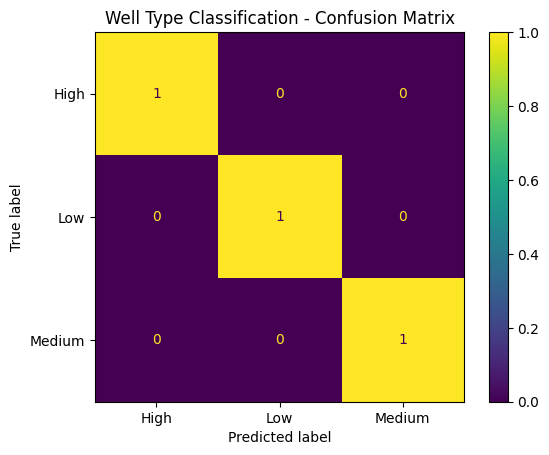

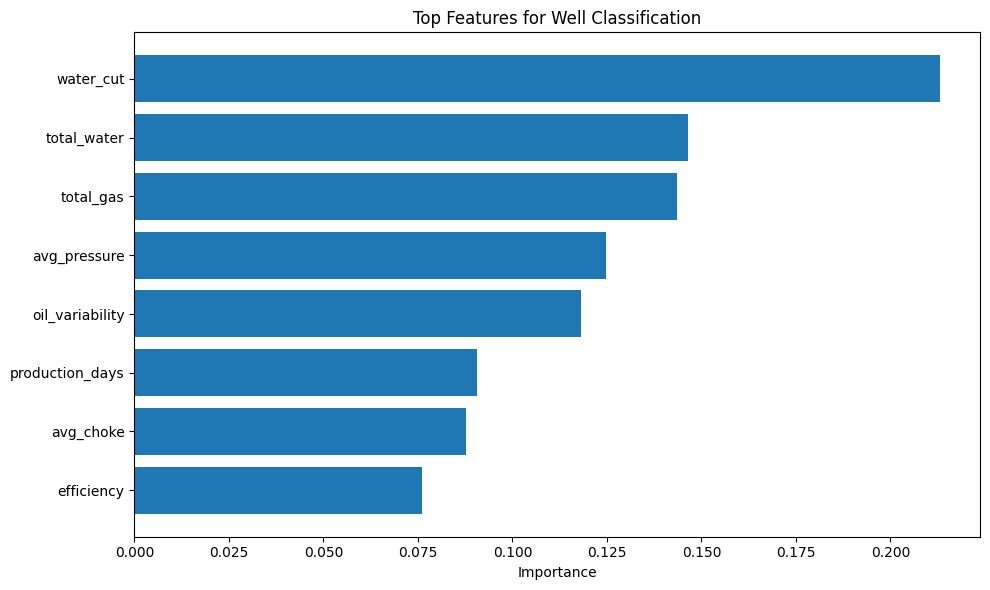


PREDICTIONS ON ALL WELLS
             well producer_type predicted_class  prediction_confidence
0   NO 15/9-F-1 C        Medium          Medium                   0.48
1  NO 15/9-F-11 H        Medium          Medium                   0.71
2  NO 15/9-F-12 H          High            High                   0.56
3  NO 15/9-F-14 H          High            High                   0.68
4  NO 15/9-F-15 D           Low             Low                   0.58
5  NO 15/9-F-4 AH           Low             Low                   0.87
6  NO 15/9-F-5 AH           Low             Low                   0.84

Confusion Matrix (All Wells):
predicted_class  High  Low  Medium
producer_type                     
High                2    0       0
Low                 0    3       0
Medium              0    0       2


In [29]:
#Machine Learning --> Well Type Classification
#Goal: Classify wells as High Producers, Medium Producers or Low Producers based on their production characteristics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans

# Load data
df = pd.read_excel('Volve production data.xlsx', sheet_name='Daily Production Data')
df
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'])

# Aggregate well-level features
well_features = []
for well in df['WELL_BORE_CODE'].unique():
    well_data = df[df['WELL_BORE_CODE'] == well]
    active_data = well_data[well_data['ON_STREAM_HRS'] > 0]
    
    if len(active_data) > 10:  # Only wells with sufficient data
        features = {
            'well': well,
            'total_oil': active_data['BORE_OIL_VOL'].sum(),
            'peak_oil_rate': active_data['BORE_OIL_VOL'].max(),
            'avg_oil_rate': active_data['BORE_OIL_VOL'].mean(),
            'total_gas': active_data['BORE_GAS_VOL'].sum(),
            'total_water': active_data['BORE_WAT_VOL'].sum(),
            'water_cut': active_data['BORE_WAT_VOL'].sum() / (active_data['BORE_OIL_VOL'].sum() + 1),
            'avg_pressure': active_data['AVG_DOWNHOLE_PRESSURE'].mean(),
            'avg_choke': active_data['AVG_CHOKE_SIZE_P'].mean(),
            'production_days': len(active_data),
            'efficiency': active_data['ON_STREAM_HRS'].mean() / 24,
            'oil_variability': active_data['BORE_OIL_VOL'].std() / (active_data['BORE_OIL_VOL'].mean() + 1)
        }
        well_features.append(features)

well_df = pd.DataFrame(well_features)
print(f"Number of wells with sufficient data: {len(well_df)}")
print(well_df[['well', 'total_oil', 'peak_oil_rate', 'water_cut']].head())

# Create target labels using K-means clustering
features_for_clustering = ['total_oil', 'peak_oil_rate', 'avg_oil_rate', 'water_cut']
X_cluster = well_df[features_for_clustering].fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-means to create 3 classes
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
well_df['producer_class'] = kmeans.fit_predict(X_scaled)

# Rename clusters by average production
class_order = well_df.groupby('producer_class')['total_oil'].mean().sort_values().index
class_mapping = {class_order[0]: 'Low', class_order[1]: 'Medium', class_order[2]: 'High'}
well_df['producer_type'] = well_df['producer_class'].map(class_mapping)

print("\nProducer Classes Distribution:")
print(well_df['producer_type'].value_counts())
print("\nClass Statistics:")
print(well_df.groupby('producer_type')['total_oil'].agg(['count', 'mean', 'min', 'max']))

# Prepare features for classification
feature_cols = ['total_gas', 'total_water', 'water_cut', 'avg_pressure', 
                'avg_choke', 'production_days', 'efficiency', 'oil_variability']
X = well_df[feature_cols].fillna(0)
y = well_df['producer_type']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nClasses in full dataset: {le.classes_}")
print(f"Class distribution: {dict(zip(*np.unique(y_encoded, return_counts=True)))}")

# FIX: Use stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, 
    stratify=y_encoded  # This ensures all classes are represented
)

# Check classes in test set
unique_in_test = np.unique(y_test)
print(f"\nClasses in test set: {le.classes_[unique_in_test]}")
print(f"Number of classes in test set: {len(unique_in_test)}")

# FIX: Get only the classes present in test set for classification report
test_classes_present = le.classes_[unique_in_test]

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

# FIX: Use only classes present in test set for the report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (only classes present in test set)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=test_classes_present))

# Cross-validation with stratified folds
cv_scores = cross_val_score(rf_clf, X, y_encoded, cv=min(5, len(np.unique(y_encoded))), 
                              scoring='accuracy')
print(f"\nCross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)
print(importance_df)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
# Only show classes that appear in test set
cm_display = ConfusionMatrixDisplay(cm, display_labels=test_classes_present)
cm_display.plot()
plt.title('Well Type Classification - Confusion Matrix')
plt.show()

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:8], importance_df['importance'][:8])
plt.xlabel('Importance')
plt.title('Top Features for Well Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Predict on all wells for business insights
well_df['predicted_class'] = le.inverse_transform(rf_clf.predict(X))
well_df['prediction_confidence'] = np.max(rf_clf.predict_proba(X), axis=1)

print("\n" + "="*60)
print("PREDICTIONS ON ALL WELLS")
print("="*60)
print(well_df[['well', 'producer_type', 'predicted_class', 'prediction_confidence']].head(10))

# Cross-tabulation of actual vs predicted
print("\nConfusion Matrix (All Wells):")
print(pd.crosstab(well_df['producer_type'], well_df['predicted_class']))